讀取模型結果...


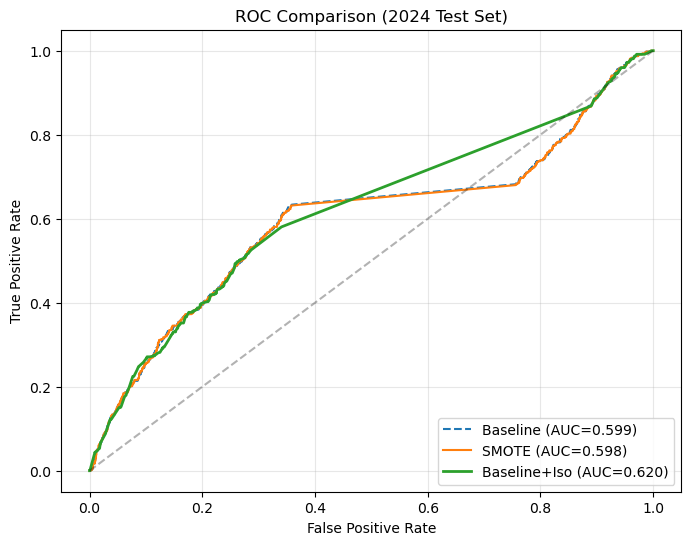

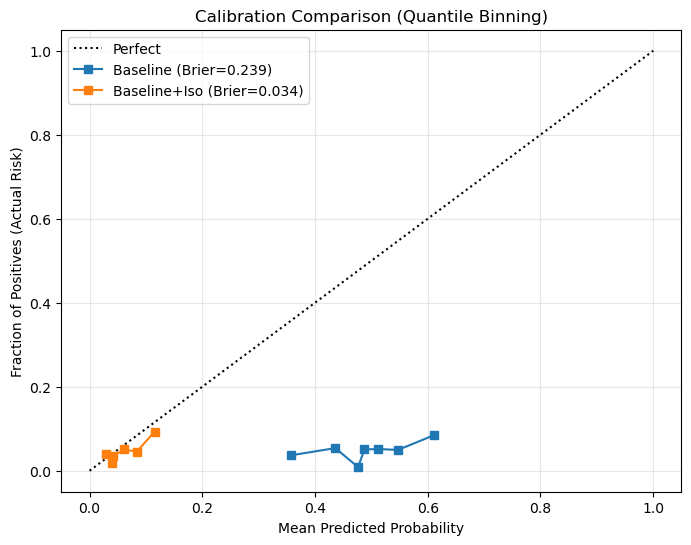

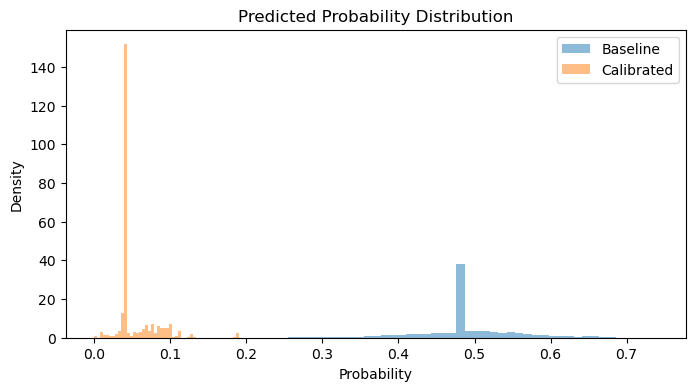


[Coefficient Interpretation]
  Feature  Coefficient
2  SIZE_t     0.316900
1   LEV_t    -0.047721
0   ROA_t    -0.119272
3   ICR_t    -0.205918


In [9]:
# 4_summary_results.ipynb
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, brier_score_loss
from sklearn.calibration import calibration_curve

# --- 設定路徑 ---
BASE_DIR = r"C:\Users\User-NB\OneDrive\Desktop\ML"
RESULT_DIR = os.path.join(BASE_DIR, "results")
DATA_PATH = os.path.join(BASE_DIR, "processed_data", "data_processed.pkl")

# 1. 讀取數據
print("讀取模型結果...")
data_info = joblib.load(DATA_PATH)
bench = joblib.load(os.path.join(RESULT_DIR, "bench_results.pkl"))
research = joblib.load(os.path.join(RESULT_DIR, "research_results.pkl"))

y_test = bench["y_test"]
p_base = bench["y_prob"]
p_smote = research["y_prob_smote"]
p_calib = research["y_prob_calib"]

# ---------------------------------------------------------
# 2. ROC Comparison (維持原樣)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, p_base)
plt.plot(fpr, tpr, label=f'Baseline (AUC={auc(fpr, tpr):.3f})', linestyle='--')

fpr_s, tpr_s, _ = roc_curve(y_test, p_smote)
plt.plot(fpr_s, tpr_s, label=f'SMOTE (AUC={auc(fpr_s, tpr_s):.3f})')

fpr_c, tpr_c, _ = roc_curve(y_test, p_calib)
plt.plot(fpr_c, tpr_c, label=f'Baseline+Iso (AUC={auc(fpr_c, tpr_c):.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.title("ROC Comparison (2024 Test Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(RESULT_DIR, "final_roc_comparison.png")) # 自動存圖
plt.show()

# ---------------------------------------------------------
# 3. Calibration Comparison (修正重點：strategy='quantile')
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], "k:", label="Perfect")

for name, probs in [("Baseline", p_base), ("Baseline+Iso", p_calib)]:
    # ★★★ 關鍵修正：加入 strategy='quantile' ★★★
    # 這樣可以強迫將樣本等分，避免點全部擠在左下角
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10, strategy='quantile')
    
    brier = brier_score_loss(y_test, probs)
    plt.plot(prob_pred, prob_true, "s-", label=f"{name} (Brier={brier:.3f})")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives (Actual Risk)")
plt.title("Calibration Comparison (Quantile Binning)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(RESULT_DIR, "final_calibration_plot.png")) # 自動存圖
plt.show()

# ---------------------------------------------------------
# 額外診斷：機率分佈圖 (這張圖可以解釋為什麼原本會擠在一起)
# ---------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.hist(p_base, bins=50, alpha=0.5, label='Baseline', density=True)
plt.hist(p_calib, bins=50, alpha=0.5, label='Calibrated', density=True)
plt.title("Predicted Probability Distribution")
plt.xlabel("Probability")
plt.ylabel("Density")
plt.legend()
plt.show()

# ---------------------------------------------------------
# 4. 係數表
# ---------------------------------------------------------
model = bench["model"]
coefs = pd.DataFrame({
    "Feature": data_info["feature_names"],
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print("\n[Coefficient Interpretation]")
print(coefs)